# OT in linar ICA

#### In this notebook, we genrate mixtures by randomly picking distributions, whether discrete or continous. We also keep at most one gaussian to confirm tractability of ICA with one gaussian. We compare how Fast ICA and OT ICA perform on 10 to 75 dima with 5 dim leap and 10,000 samples wiht max of 150 starts in phase 1 SGD step and phase 2 incorporating Stiefel manifold.

In [1]:
import numpy as np
import torch
import pandas as pd
import time
from sklearn.decomposition import FastICA
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import warnings
from sklearn.exceptions import ConvergenceWarning

from wasserstein_ica import WassersteinICA

In [8]:
# ==========================================
# Thesis Theme Configuration
# ==========================================
def set_thesis_theme():
    thesis_colors = ['#0173B2', '#DE8F05', '#029E73', '#D55E00', '#CC78BC', '#CA9161']
    plt.rcParams.update({
        'figure.figsize': (10, 6),
        'figure.dpi': 300,
        'axes.prop_cycle': plt.cycler(color=thesis_colors),
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linestyle': '--',
        'axes.axisbelow': True,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'font.size': 12,
        'axes.titlesize': 14,
        'axes.labelsize': 12,
        'legend.frameon': True,
        'legend.fontsize': 11,
        'lines.linewidth': 2.5
    })
set_thesis_theme()

In [2]:
def amari_error(W, A):
    """
    Computes the Amari Error to evaluate the performance of ICA.
    An error close to 0 indicates perfect separation.
    
    W: Estimated unmixing matrix (n_components, n_features)
    A: True mixing matrix (n_features, n_sources)
    """
    # P is the global matrix representing the combined effect of mixing and unmixing
    P = np.dot(W, A)
    P_abs = np.abs(P)
    
    # 1. Sum of row-wise errors
    row_max = np.max(P_abs, axis=1, keepdims=True)
    row_term = np.sum(P_abs / row_max, axis=1) - 1.0
    
    # 2. Sum of column-wise errors
    col_max = np.max(P_abs, axis=0, keepdims=True)
    col_term = np.sum(P_abs / col_max, axis=0) - 1.0
    
    # Average over the number of components
    n = P.shape[0]
    return (np.sum(row_term) + np.sum(col_term)) / (2 * n)

In [3]:
# ==========================================
# 1. The Generalized Hybrid Mixture Generator
# ==========================================

def generate_general_mixture(n_dim, n_samples, seed=None):
    """
    Generates a generalized ICA dataset.
    Ensures exactly ONE source is Gaussian.
    Randomly pulls the remaining (n_dim - 1) sources from a diverse pool 
    of discrete and continuous non-Gaussian distributions.
    """
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)

    sources = []
    
    # 1. Inject Exactly ONE Gaussian Source
    sources.append(np.random.normal(0, 1, size=n_samples))
    
    # 2. Define the Non-Gaussian Pool (all naturally or explicitly standardized)
    def gen_laplace(): 
        return np.random.laplace(0, 1 / np.sqrt(2), size=n_samples)
    def gen_bernoulli(): 
        return np.random.choice([-1.0, 1.0], size=n_samples)
    def gen_uniform(): 
        return np.random.uniform(-np.sqrt(3), np.sqrt(3), size=n_samples)
    def gen_student_t(): 
        s = np.random.standard_t(df=3, size=n_samples)
        return s / np.std(s) # Standardize due to heavy tails
    def gen_poisson():
        s = np.random.poisson(lam=3, size=n_samples)
        return (s - np.mean(s)) / np.std(s) # Center and scale
    def gen_binomial():
        s = np.random.binomial(n=10, p=0.5, size=n_samples)
        return (s - np.mean(s)) / np.std(s) # Center and scale
    def gen_chisquare():
        s = np.random.chisquare(df=2, size=n_samples)
        return (s - np.mean(s)) / np.std(s) # Center and scale
    def gen_exponential():
        s = np.random.exponential(scale=1.0, size=n_samples)
        return (s - np.mean(s)) / np.std(s) # Center and scale
        
    pool = [gen_laplace, gen_bernoulli, gen_uniform, gen_student_t, 
            gen_poisson, gen_binomial, gen_chisquare, gen_exponential]
            
    # 3. Generate the remaining (n_dim - 1) sources
    for _ in range(n_dim - 1):
        # Select a random distribution generator from the pool
        generator = np.random.choice(pool)
        sources.append(generator())
        
    S = np.stack(sources)
    
    # Shuffle the rows so the Gaussian source is at a random index
    np.random.shuffle(S)
    
    # 4. Generate a well-conditioned mixing matrix
    cond_num = 1000
    while cond_num > 100:
        A = np.random.randn(n_dim, n_dim)
        cond_num = np.linalg.cond(A)
        
    X = A @ S
    return torch.tensor(X, dtype=torch.float32), A

In [4]:
# ==========================================
# 2. Parallel Worker Function (GPU Enabled)
# ==========================================

def run_general_trial(dim, trial, n_samples, compute_level):
    torch.set_num_threads(1) 
    trial_results = []
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    X_torch, A_true = generate_general_mixture(n_dim=dim, n_samples=n_samples, seed=trial)
    X_torch = X_torch.to(device)
    X_np = X_torch.cpu().numpy()
    
    # Configure Compute Parameters
    if compute_level == 'Low Compute':
        fast_max_iter = 1000
        w2_restarts = min(dim * 4, 150)
        w2_def_iter = 150
        w2_sym_iter = 300
    else: # High Compute
        fast_max_iter = 10000 # Test if infinite iterations help FastICA
        w2_restarts = min(dim * 15, 600) 
        w2_def_iter = 300
        w2_sym_iter = 800
    
    # --- FastICA ---
    try:
        # We allow ConvergenceWarnings to trigger naturally in the console
        fast_ica = FastICA(n_components=dim, max_iter=fast_max_iter, tol=1e-4, random_state=trial)
        fast_ica.fit(X_np.T)
        W_fast_total = fast_ica.components_
        score_fast = amari_error(W_fast_total, A_true)
    except Exception:
        score_fast = np.nan
        
    trial_results.append({
        'Dimension': dim, 
        'Method': 'FastICA', 
        'Compute Level': compute_level,
        'Amari Error': score_fast
    })
    
    # --- OT-ICA (Stiefel) ---
    try:
        ica = WassersteinICA(X_torch)
        ica.whiten()
        W_white_np = ica.W_white.cpu().numpy()
        
        extracted_ws = []
        
        # 1. Deflation Phase
        for _ in range(dim):
            prev = torch.stack(extracted_ws) if extracted_ws else None
            w, _ = ica.optimize_wasserstein2(
                prev_components=prev, 
                max_iter=w2_def_iter, 
                n_restarts=w2_restarts, 
                dither_sigma=0.01
            )
            extracted_ws.append(w)
            
        W_deflation_init = torch.stack(extracted_ws)
        
        # 2. Symmetric Stiefel Phase 
        W_stiefel_unmixed = ica.optimize_symmetric(
            n_components=dim, 
            max_iter=w2_sym_iter,        
            lr=0.25,             
            init_w=W_deflation_init, 
            optimizer='stiefel',
            use_sinkhorn=False,
            dither_sigma=0.01,   
            batch_size=1024      
        )
        W_wass_total = W_stiefel_unmixed.cpu().numpy() @ W_white_np
        score_wass = amari_error(W_wass_total, A_true)
        
    except Exception as e:
        score_wass = np.nan
        
    trial_results.append({
        'Dimension': dim, 
        'Method': 'OT-ICA', 
        'Compute Level': compute_level,
        'Amari Error': score_wass
    })
    
    return trial_results

In [6]:
# ==========================================
# 3. Execution & Plotting
# ==========================================
DIMENSIONS = list(range(10, 71, 5)) 
N_SAMPLES = 10000 
COMPUTE_LEVELS = ['Low Compute', 'High Compute']
N_TRIALS = 5

tasks = [(dim, trial, N_SAMPLES, comp) 
         for dim in DIMENSIONS 
         for trial in range(N_TRIALS) 
         for comp in COMPUTE_LEVELS]

results_nested = Parallel(n_jobs=4)(
    delayed(run_general_trial)(dim, trial, n_samples, comp) 
    for dim, trial, n_samples, comp in tqdm(tasks)
)

df_general = pd.DataFrame([item for sublist in results_nested for item in sublist])

  0%|          | 0/130 [00:00<?, ?it/s]

/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  war

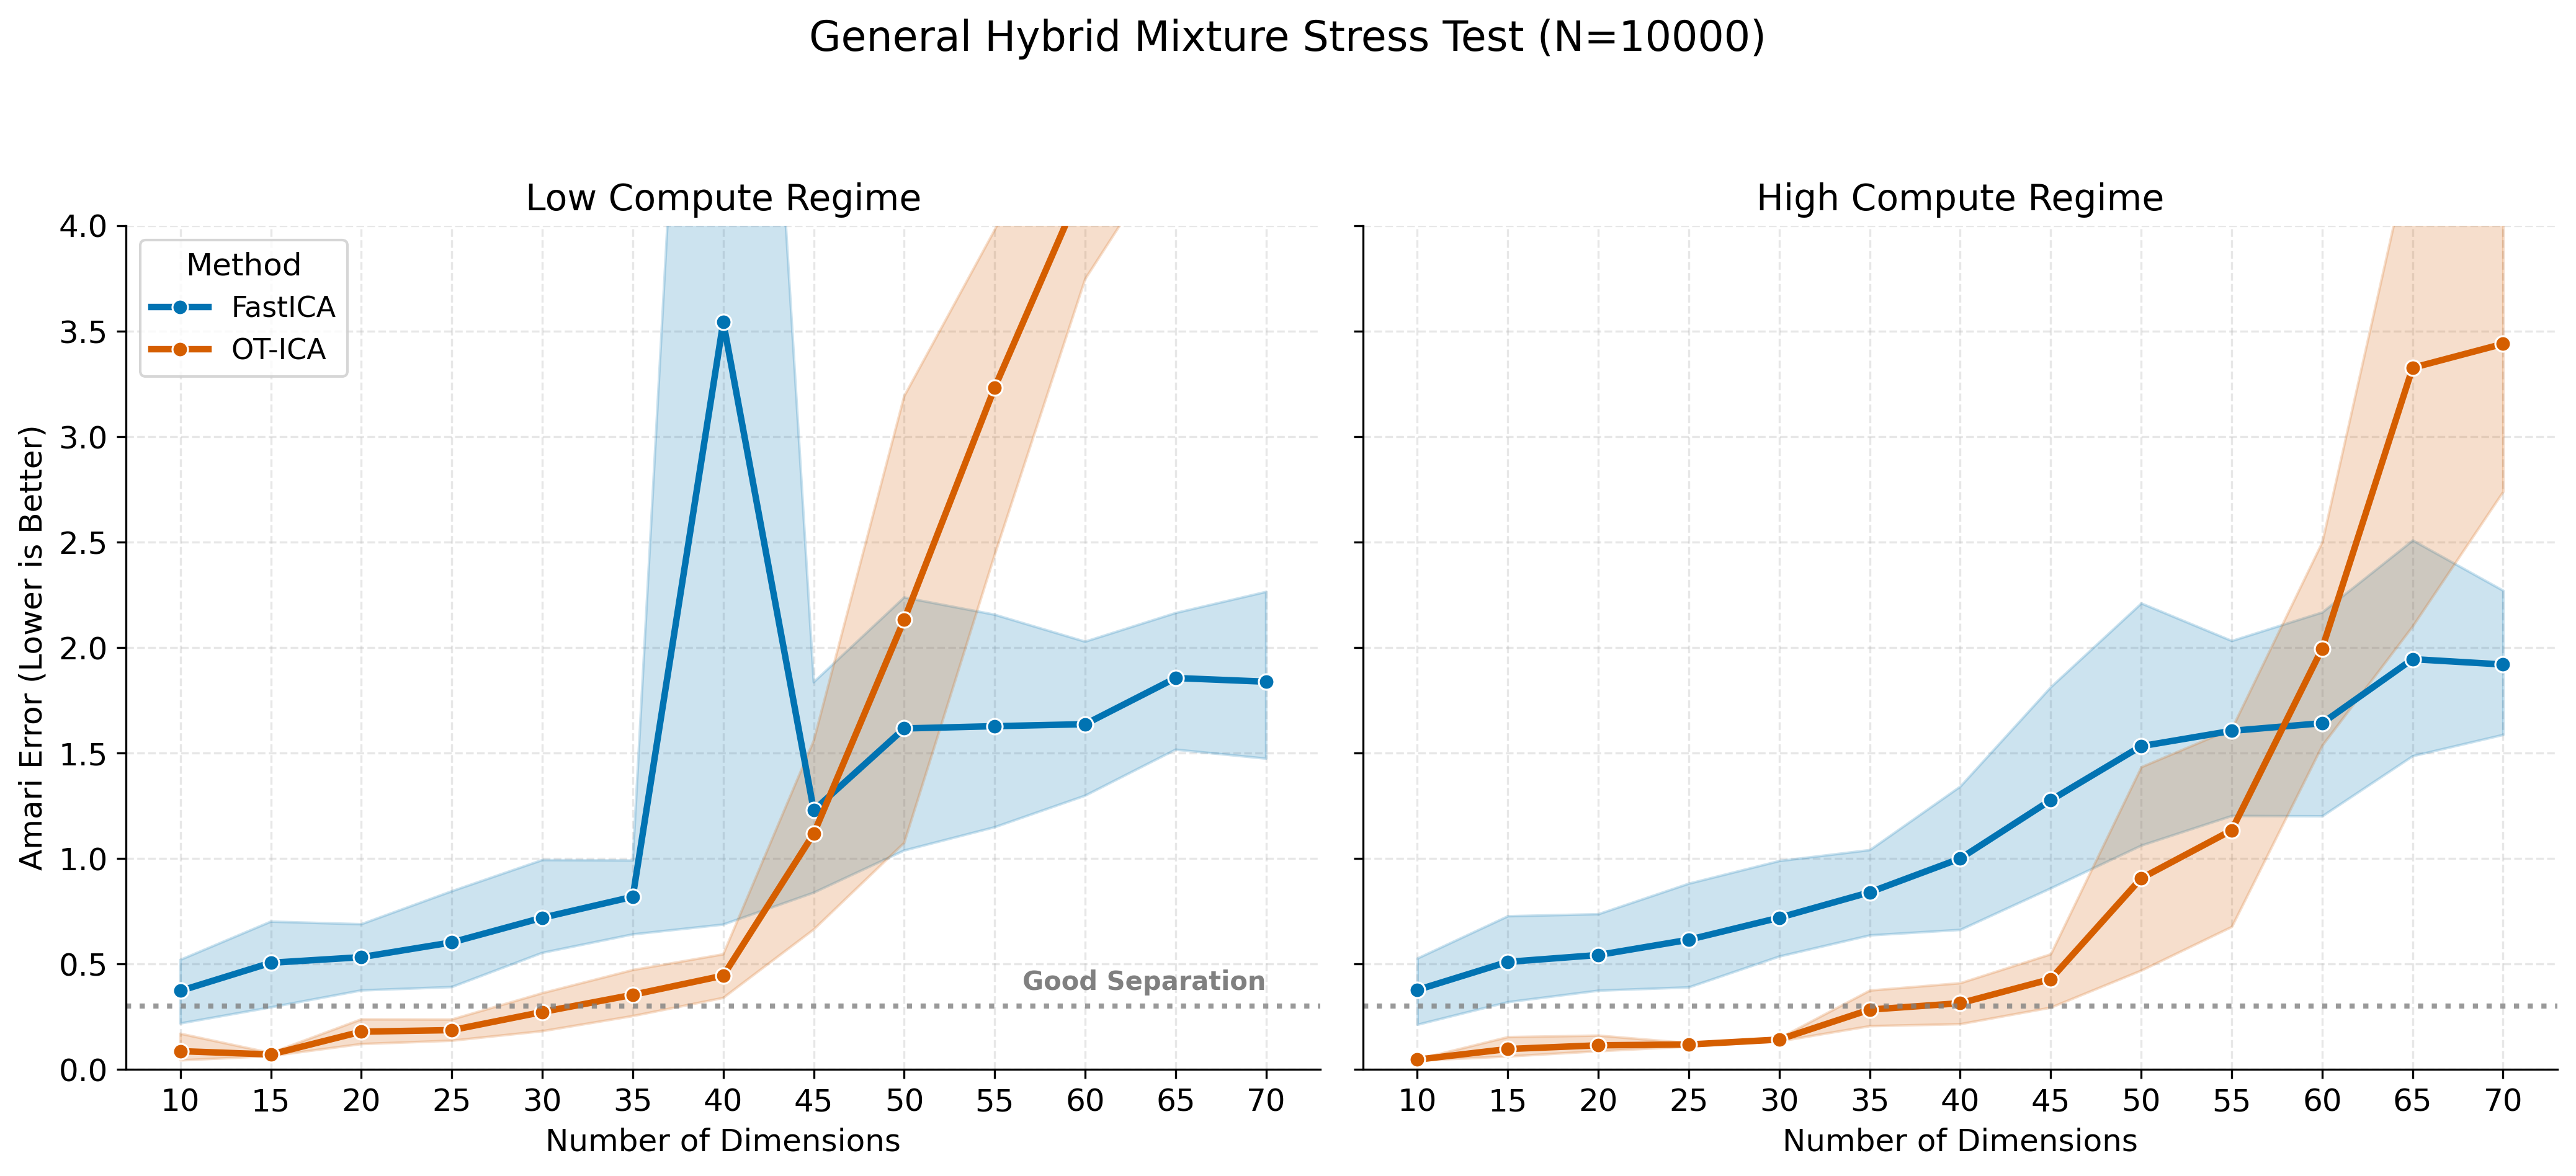

In [10]:
# ==========================================
# 4. Plotting the Results
# ==========================================
# Ensure theme is applied first
set_thesis_theme()

# --- Side-by-Side Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
palette = {'FastICA': '#0173B2', 'OT-ICA': '#D55E00'}

for idx, comp in enumerate(COMPUTE_LEVELS):
    sns.lineplot(
        data=df_general[df_general['Compute Level'] == comp], 
        x='Dimension', y='Amari Error', hue='Method', 
        palette=palette, marker='o', linewidth=2.5, ax=axes[idx]
    )
    
    # Force grid to appear
    axes[idx].grid(True, linestyle='--', alpha=0.3)
    
    axes[idx].set_title(f"{comp} Regime", fontsize=14)
    axes[idx].set_xlabel("Number of Dimensions", fontsize=12)
    axes[idx].set_xticks(DIMENSIONS)
    
    # The dotted gray line
    axes[idx].axhline(0.3, color='gray', linestyle=':', alpha=0.8, linewidth=2)
    
    # Add text to the first graph (Left Plot)
    if idx == 0:
        axes[idx].set_ylabel("Amari Error (Lower is Better)", fontsize=12)
        axes[idx].legend(title='Method', loc='upper left')
        
        # Annotation: x is the max dimension, y is slightly above the line
        axes[idx].text(
            x=max(DIMENSIONS), y=0.35, 
            s='Good Separation', 
            color='gray', 
            fontsize=10, 
            fontweight='bold',
            ha='right',          # Horizontal alignment: Right
            va='bottom'          # Vertical alignment: Bottom
        )
    else:
        axes[idx].set_ylabel("")
        if axes[idx].get_legend(): axes[idx].get_legend().remove()

# Apply Y-limit and 0.5 ticks
plt.ylim(0, 4)
from matplotlib.ticker import MultipleLocator
axes[0].yaxis.set_major_locator(MultipleLocator(0.5))

fig.suptitle(f"General Hybrid Mixture Stress Test (N={N_SAMPLES})", fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('hybrid_mixture_amari_compute.png', dpi=300, bbox_inches='tight')
plt.show()

### We run an experiment investigating why FastICA fails, we increase iterations and tolerances to help it converge. This helps us verify if Fast ICa fails on principle in this general mixture setting or compute power.

In [ ]:
"""
import numpy as np
import pandas as pd
import warnings
from sklearn.decomposition import FastICA
from sklearn.exceptions import ConvergenceWarning
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
"""

--- FastICA Limits: The Oscillation Test ---


Running FastICA configs:   0%|          | 0/210 [00:00<?, ?it/s]

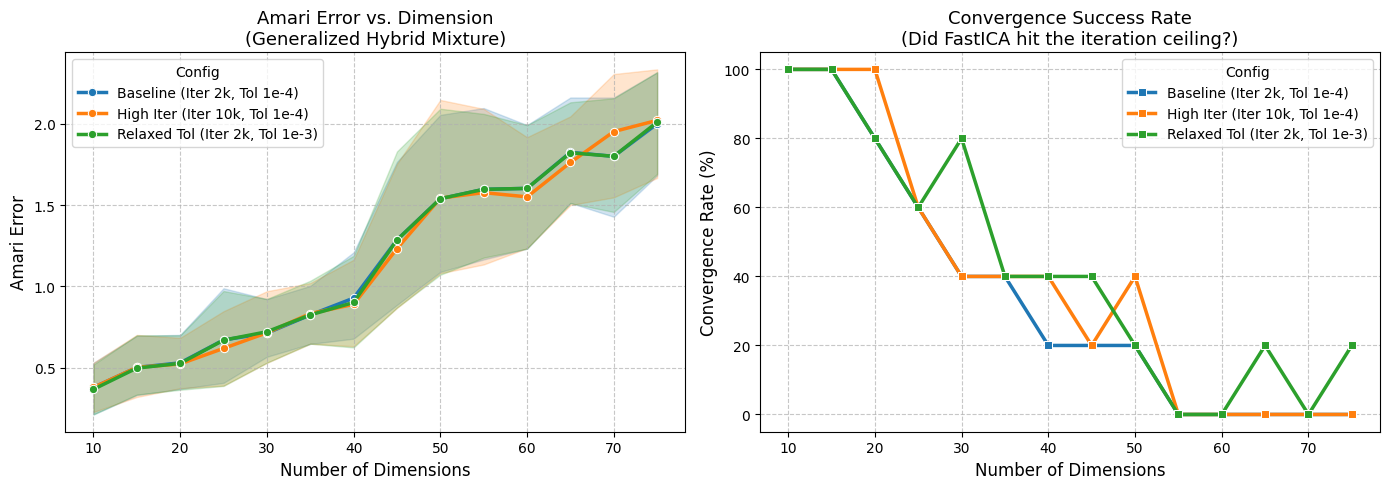

Config,"Baseline (Iter 2k, Tol 1e-4)","High Iter (Iter 10k, Tol 1e-4)","Relaxed Tol (Iter 2k, Tol 1e-3)"
Dimension,,,
10,0.3794,0.3794,0.3678
15,0.5025,0.5025,0.4982
20,0.5304,0.5238,0.5270
25,0.6711,0.6193,0.6698
30,0.7127,0.7150,0.7216
35,0.8250,0.8331,0.8252
40,0.9284,0.8900,0.9014
45,1.2865,1.2327,1.2853
50,1.5391,1.5432,1.5394


In [8]:
"""
# ==========================================
# 2. Worker Function
# ==========================================

def run_fastica_config(dim, trial, n_samples, config_name, max_iter, tol):
    X_np, A_true = generate_general_mixture(n_dim=dim, n_samples=n_samples, seed=trial)
    
    converged = True
    
    # Catch warnings to suppress console spam and log convergence status
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always", ConvergenceWarning)
        
        try:
            fast_ica = FastICA(n_components=dim, max_iter=max_iter, tol=tol, random_state=trial)
            fast_ica.fit(X_np.T)
            W_fast = fast_ica.components_
            score = amari_error(W_fast, A_true)
            
            # If a ConvergenceWarning was caught, flag it
            if len(w) > 0:
                converged = False
                
        except Exception:
            score = np.nan
            converged = False

    return {
        'Dimension': dim, 
        'Config': config_name, 
        'Amari Error': score,
        'Converged': int(converged)  # 1 for Yes, 0 for No
    }

# ==========================================
# 3. Main Execution
# ==========================================

DIMENSIONS = list(range(10, 80, 5)) 
N_SAMPLES = 10000 
N_TRIALS = 5

CONFIGS = [
    ("Baseline (Iter 2k, Tol 1e-4)", 2000, 1e-4),
    ("High Iter (Iter 10k, Tol 1e-4)", 10000, 1e-4),
    ("Relaxed Tol (Iter 2k, Tol 1e-3)", 2000, 1e-3)
]

print("--- FastICA Limits: The Oscillation Test ---")

tasks = [(dim, trial, N_SAMPLES, c_name, m_iter, tol) 
         for dim in DIMENSIONS 
         for trial in range(N_TRIALS) 
         for (c_name, m_iter, tol) in CONFIGS]

results = []
with Parallel(n_jobs=8, return_as="generator") as parallel:
    jobs = (delayed(run_fastica_config)(*task) for task in tasks)
    for res in tqdm(parallel(jobs), total=len(tasks), desc="Running FastICA configs"):
        results.append(res)

df_fast = pd.DataFrame(results)

# ==========================================
# 4. Plotting
# ==========================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Amari Error
sns.lineplot(data=df_fast, x='Dimension', y='Amari Error', hue='Config', marker='o', linewidth=2.5, ax=ax1)
ax1.set_title("Amari Error vs. Dimension\n(Generalized Hybrid Mixture)", fontsize=13)
ax1.set_ylabel("Amari Error", fontsize=12)
ax1.set_xlabel("Number of Dimensions", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Convergence Rate
# Calculate percentage of successful convergences
df_conv = df_fast.groupby(['Dimension', 'Config'])['Converged'].mean().reset_index()
df_conv['Converged'] *= 100 # Convert to percentage

sns.lineplot(data=df_conv, x='Dimension', y='Converged', hue='Config', marker='s', linewidth=2.5, ax=ax2)
ax2.set_title("Convergence Success Rate\n(Did FastICA hit the iteration ceiling?)", fontsize=13)
ax2.set_ylabel("Convergence Rate (%)", fontsize=12)
ax2.set_xlabel("Number of Dimensions", fontsize=12)
ax2.set_ylim(-5, 105)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Display summary table of Amari Errors
display(df_fast.groupby(['Dimension', 'Config'])['Amari Error'].mean().unstack().round(4))
"""

#### Now We explore whether the FastICA is failing due to discrete distributions, some continous distribution, or the one gaussian we added. We will try at 30 and 40 dimensions at 10,000 samples. Ablation Study.

In [9]:
import numpy as np
import pandas as pd
import warnings
from sklearn.decomposition import FastICA
from sklearn.exceptions import ConvergenceWarning
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# ==========================================
# 1. The Ablation Data Generator
# ==========================================
def generate_ablation_mixture(n_dim, n_samples, pool_type, seed=None):
    """
    Generates datasets based on specific sub-pools to isolate FastICA's failure modes.
    """
    if seed is not None:
        np.random.seed(seed)
    
    # Standardized generators
    def gen_laplace(): return np.random.laplace(0, 1/np.sqrt(2), size=n_samples)
    def gen_bernoulli(): return np.random.choice([-1.0, 1.0], size=n_samples)
    def gen_uniform(): return np.random.uniform(-np.sqrt(3), np.sqrt(3), size=n_samples)
    def gen_student_t(): 
        s = np.random.standard_t(df=3, size=n_samples)
        return s / np.std(s)
    def gen_poisson():
        s = np.random.poisson(lam=3, size=n_samples) 
        return (s - np.mean(s)) / np.std(s)
    def gen_binomial():
        s = np.random.binomial(n=10, p=0.5, size=n_samples) # do an experiment varying n and p
        return (s - np.mean(s)) / np.std(s)
    def gen_chisquare():
        s = np.random.chisquare(df=2, size=n_samples)
        return (s - np.mean(s)) / np.std(s)
    def gen_exponential():
        s = np.random.exponential(scale=1.0, size=n_samples)
        return (s - np.mean(s)) / np.std(s)

    # Define the sub-pools
    pools = {
        'Full Hybrid': [gen_laplace, gen_bernoulli, gen_uniform, gen_student_t, 
                        gen_poisson, gen_binomial, gen_chisquare, gen_exponential],
        'Continuous Only': [gen_laplace, gen_uniform, gen_student_t, gen_chisquare, gen_exponential],
        'Discrete Only': [gen_bernoulli, gen_poisson, gen_binomial],
        'Strictly Super-Gaussian': [gen_laplace, gen_student_t, gen_chisquare, gen_exponential],
        'Zero Gaussian': [gen_laplace, gen_bernoulli, gen_uniform, gen_student_t, 
                          gen_poisson, gen_binomial, gen_chisquare, gen_exponential]
    }
    
    active_pool = pools[pool_type]
    sources = []
    
    # Inject Gaussian rule
    if pool_type != 'Zero Gaussian':
        sources.append(np.random.normal(0, 1, size=n_samples))
        n_to_generate = n_dim - 1
    else:
        n_to_generate = n_dim

    # Generate the rest
    for _ in range(n_to_generate):
        sources.append(np.random.choice(active_pool)())
        
    S = np.stack(sources)
    np.random.shuffle(S) # Hide the Gaussian
    
    cond_num = 1000
    while cond_num > 100:
        A = np.random.randn(n_dim, n_dim)
        cond_num = np.linalg.cond(A)
        
    X = A @ S
    return X, A

In [11]:
# ==========================================
# 2. The Worker Function
# ==========================================
def run_ablation_trial(dim, trial, n_samples, pool_type):
    X_np, A_true = generate_ablation_mixture(n_dim=dim, n_samples=n_samples, pool_type=pool_type, seed=trial)
    
    converged = True
    
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always", ConvergenceWarning)
        
        try:
            # Using standard baseline config that failed previously
            fast_ica = FastICA(n_components=dim, max_iter=2000, tol=1e-4, random_state=trial)
            fast_ica.fit(X_np.T)
            W_fast = fast_ica.components_
            score = amari_error(W_fast, A_true)
            
            if len(w) > 0:
                converged = False
                
        except Exception:
            score = np.nan
            converged = False

    return {
        'Dimension': dim, 
        'Pool Type': pool_type, 
        'Amari Error': score,
        'Converged': int(converged)
    }

In [12]:
# ==========================================
# 3. Main Execution
# ==========================================
DIMENSIONS = [30, 40]
N_SAMPLES = 10000 
N_TRIALS = 5
POOL_TYPES = ['Full Hybrid', 'Continuous Only', 'Discrete Only', 'Strictly Super-Gaussian', 'Zero Gaussian']

print("--- FastICA Ablation Study: Isolating the Failure Mode ---")

tasks = [(dim, trial, N_SAMPLES, p_type) 
         for dim in DIMENSIONS 
         for trial in range(N_TRIALS) 
         for p_type in POOL_TYPES]

results = []
with Parallel(n_jobs=8, return_as="generator") as parallel:
    jobs = (delayed(run_ablation_trial)(*task) for task in tasks)
    for res in tqdm(parallel(jobs), total=len(tasks), desc="Running Ablation Pools"):
        results.append(res)

df_ablation = pd.DataFrame(results)

--- FastICA Ablation Study: Isolating the Failure Mode ---


Running Ablation Pools:   0%|          | 0/50 [00:00<?, ?it/s]

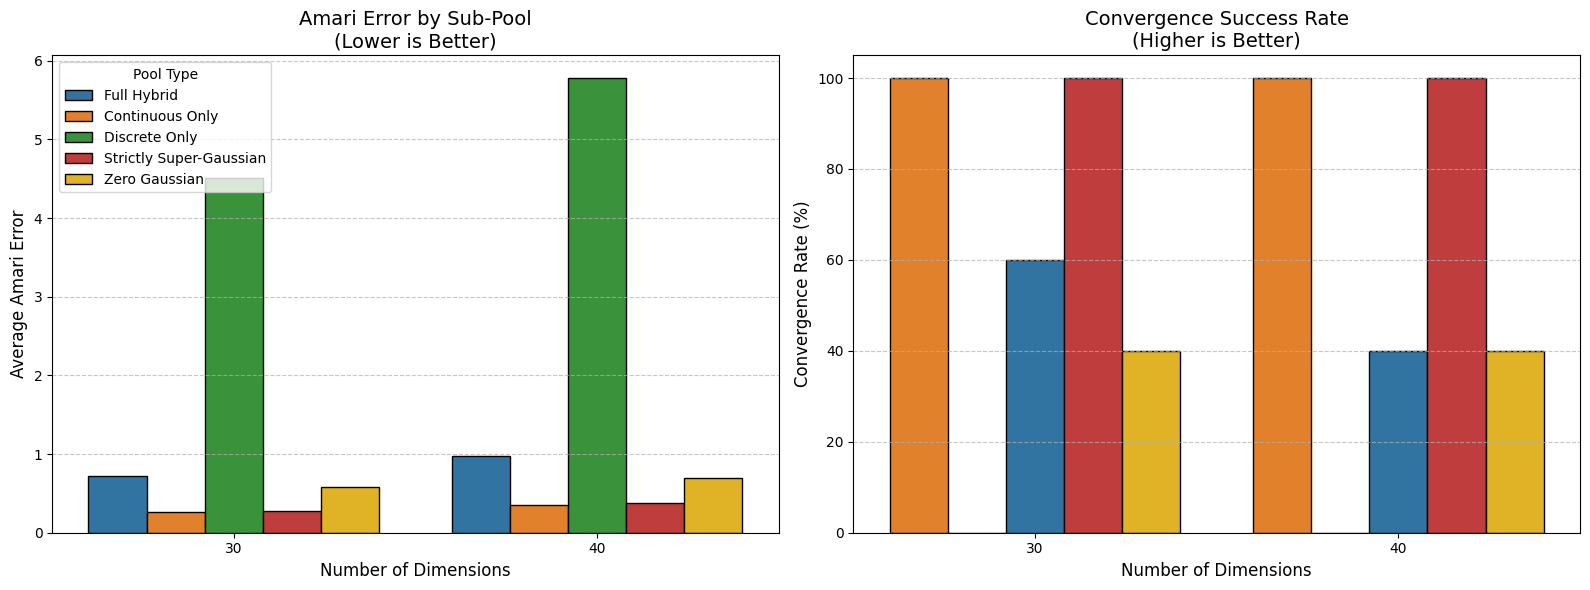

Amari Error  Converged
Dimension Pool Type                                      
30        Continuous Only               0.2672        1.0
          Discrete Only                 4.5073        0.0
          Full Hybrid                   0.7225        0.6
          Strictly Super-Gaussian       0.2813        1.0
          Zero Gaussian                 0.5771        0.4
40        Continuous Only               0.3545        1.0
          Discrete Only                 5.7794        0.0
          Full Hybrid                   0.9800        0.4
          Strictly Super-Gaussian       0.3764        1.0
          Zero Gaussian                 0.6935        0.4

In [13]:
# ==========================================
# 4. Plotting the Results
# ==========================================
# Calculate convergence percentage
df_conv = df_ablation.groupby(['Dimension', 'Pool Type'])['Converged'].mean().reset_index()
df_conv['Converged'] *= 100

# Set up the matplotlib figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Define an exact, highly distinguishable custom color palette
custom_palette = {
    'Full Hybrid': '#1f77b4',             # Blue
    'Continuous Only': '#ff7f0e',         # Orange
    'Discrete Only': '#2ca02c',           # Green
    'Strictly Super-Gaussian': '#d62728', # Red
    'Zero Gaussian': '#ffc107'            # Yellow/Gold (for better contrast)
}

# Plot 1: Amari Error Bar Chart
sns.barplot(data=df_ablation, x='Dimension', y='Amari Error', hue='Pool Type', 
            palette=custom_palette, edgecolor='black', ax=ax1, errorbar=None)
ax1.set_title("Amari Error by Sub-Pool\n(Lower is Better)", fontsize=14)
ax1.set_ylabel("Average Amari Error", fontsize=12)
ax1.set_xlabel("Number of Dimensions", fontsize=12)
ax1.grid(True, axis='y', linestyle='--', alpha=0.7)

# Plot 2: Convergence Rate Bar Chart
sns.barplot(data=df_conv, x='Dimension', y='Converged', hue='Pool Type', 
            palette=custom_palette, edgecolor='black', ax=ax2)
ax2.set_title("Convergence Success Rate\n(Higher is Better)", fontsize=14)
ax2.set_ylabel("Convergence Rate (%)", fontsize=12)
ax2.set_xlabel("Number of Dimensions", fontsize=12)
ax2.set_ylim(0, 105)
ax2.grid(True, axis='y', linestyle='--', alpha=0.7)

# Adjust legends
ax1.legend(title='Pool Type', loc='upper left')
ax2.legend_.remove() # Remove duplicate legend

plt.tight_layout()
plt.show()

# Print the numerical summary
display(df_ablation.groupby(['Dimension', 'Pool Type'])[['Amari Error', 'Converged']].mean().round(4))

#### same ablation study but with W ICA

In [14]:
# ==========================================
# Worker Function for OT-ICA Ablation Study
# ==========================================
def run_ablation_trial_ot(dim, trial, n_samples, pool_type):
    # Ensure thread safety for parallel processing
    torch.set_num_threads(1) 
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # 1. Generate the isolated sub-pool data
    X_np, A_true = generate_ablation_mixture(n_dim=dim, n_samples=n_samples, pool_type=pool_type, seed=trial)
    X_torch = torch.tensor(X_np, dtype=torch.float32).to(device)
    
    converged = True
    score = np.nan
    
    try:
        # 2. Initialize and whiten
        ica = WassersteinICA(X_torch)
        ica.whiten()
        W_white_np = ica.W_white.cpu().numpy()
        
        extracted_ws = []
        # Cap restarts to match your notebook's logic
        n_restarts = dim * 4 if dim * 4 < 150 else 150
        
        # 3. Deflation Phase (with dithering for discrete sources)
        for _ in range(dim):
            prev = torch.stack(extracted_ws) if extracted_ws else None
            w, _ = ica.optimize_wasserstein2(
                prev_components=prev, 
                max_iter=200, 
                n_restarts=n_restarts, 
                dither_sigma=0.01
            )
            extracted_ws.append(w)
            
        W_deflation_init = torch.stack(extracted_ws)
        
        # 4. Symmetric Stiefel Phase 
        W_stiefel_unmixed = ica.optimize_symmetric(
            n_components=dim, 
            max_iter=400,        
            lr=0.25,             
            init_w=W_deflation_init, 
            optimizer='stiefel',
            use_sinkhorn=False,
            dither_sigma=0.01,   
            batch_size=1024      
        )
        
        # Calculate final combined mixing matrix and score
        W_wass_total = W_stiefel_unmixed.cpu().numpy() @ W_white_np
        score = amari_error(W_wass_total, A_true)
        
    except Exception as e:
        # If OT ICA diverges or throws a PyTorch error, we log it as failed convergence
        converged = False
        score = np.nan

    return {
        'Dimension': dim, 
        'Pool Type': pool_type, 
        'Amari Error': score,
        'Converged': int(converged)
    }

In [15]:
# ==========================================
# Run the OT ICA Ablation Experiment
# ==========================================
import time

DIMENSIONS = [30, 40]
POOL_TYPES = [
    'Continuous Only', 
    'Discrete Only', 
    'Full Hybrid', 
    'Strictly Super-Gaussian', 
    'Zero Gaussian'
]
N_SAMPLES = 10000
N_TRIALS = 5 # Set to 5 based on previous tables, adjust if you want more robust averages

print(f"Starting OT-ICA Ablation Study...")
print(f"Dimensions: {DIMENSIONS}")
print(f"Pools: {POOL_TYPES}")
print(f"Trials per config: {N_TRIALS}")

start_time = time.time()

# Run in parallel to speed up the process (same syntax as your FastICA cell)
results_ot = Parallel(n_jobs=-1)(
    delayed(run_ablation_trial_ot)(dim, trial, N_SAMPLES, pool_type)
    for dim in DIMENSIONS
    for pool_type in POOL_TYPES
    for trial in range(N_TRIALS)
)

print(f"Finished in {(time.time() - start_time)/60:.2f} minutes.")

# Compile results into a DataFrame
df_ablation_ot = pd.DataFrame(results_ot)

Starting OT-ICA Ablation Study...
Dimensions: [30, 40]
Pools: ['Continuous Only', 'Discrete Only', 'Full Hybrid', 'Strictly Super-Gaussian', 'Zero Gaussian']
Trials per config: 5
Finished in 9.12 minutes.


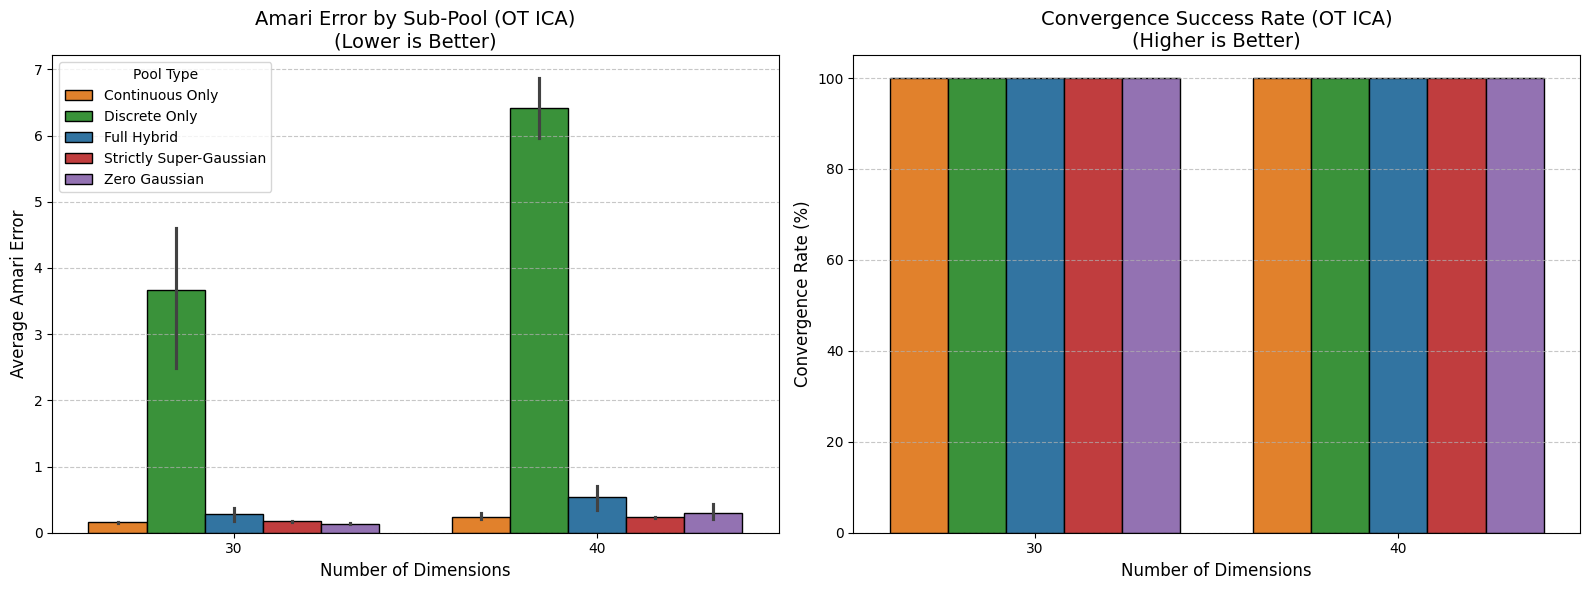

Amari Error  Converged
Dimension Pool Type                                      
30        Continuous Only               0.1598        1.0
          Discrete Only                 3.6605        1.0
          Full Hybrid                   0.2797        1.0
          Strictly Super-Gaussian       0.1759        1.0
          Zero Gaussian                 0.1380        1.0
40        Continuous Only               0.2412        1.0
          Discrete Only                 6.4085        1.0
          Full Hybrid                   0.5367        1.0
          Strictly Super-Gaussian       0.2322        1.0
          Zero Gaussian                 0.3007        1.0

In [16]:
# ==========================================
# Plotting the OT ICA Results
# ==========================================

# Calculate convergence percentage
df_conv_ot = df_ablation_ot.groupby(['Dimension', 'Pool Type'])['Converged'].mean().reset_index()
df_conv_ot['Converged'] *= 100

# Set up the matplotlib figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Exact palette from your notebook
custom_palette = {
    'Full Hybrid': '#1f77b4',             # Blue
    'Continuous Only': '#ff7f0e',         # Orange
    'Discrete Only': '#2ca02c',           # Green
    'Strictly Super-Gaussian': '#d62728', # Red
    'Zero Gaussian': '#9467bd'            # Purple
}

# Plot 1: Amari Error Bar Chart
sns.barplot(data=df_ablation_ot, x='Dimension', y='Amari Error', hue='Pool Type', 
            palette=custom_palette, edgecolor='black', ax=ax1)
ax1.set_title("Amari Error by Sub-Pool (OT ICA)\n(Lower is Better)", fontsize=14)
ax1.set_ylabel("Average Amari Error", fontsize=12)
ax1.set_xlabel("Number of Dimensions", fontsize=12)
ax1.grid(True, axis='y', linestyle='--', alpha=0.7)

# Plot 2: Convergence Rate Bar Chart
sns.barplot(data=df_conv_ot, x='Dimension', y='Converged', hue='Pool Type', 
            palette=custom_palette, edgecolor='black', ax=ax2)
ax2.set_title("Convergence Success Rate (OT ICA)\n(Higher is Better)", fontsize=14)
ax2.set_ylabel("Convergence Rate (%)", fontsize=12)
ax2.set_xlabel("Number of Dimensions", fontsize=12)
ax2.set_ylim(0, 105)
ax2.grid(True, axis='y', linestyle='--', alpha=0.7)

# Adjust legends
ax1.legend(title='Pool Type', loc='upper left')
ax2.legend_.remove() # Remove duplicate legend

plt.tight_layout()
plt.show()

# Print the final numerical summary equivalent to your screenshot
display(df_ablation_ot.groupby(['Dimension', 'Pool Type'])[['Amari Error', 'Converged']].mean().round(4))

#### Fast ICA only discrete but seperate, Bernouli, Poisson, Binomial

In [17]:
# ==========================================
# 1. Single Discrete Distribution Generator
# ==========================================
def generate_single_discrete_mixture(n_dim, n_samples, dist_type, seed=None):
    """
    Generates a mixture with 1 Gaussian and (n_dim - 1) sources of a SINGLE discrete type.
    """
    if seed is not None:
        np.random.seed(seed)
        
    sources = []
    # 1 Gaussian for baseline tractability
    sources.append(np.random.normal(0, 1, size=n_samples))
    
    for _ in range(n_dim - 1):
        if dist_type == 'Bernoulli':
            s = np.random.choice([-1.0, 1.0], size=n_samples)
        elif dist_type == 'Poisson':
            s = np.random.poisson(lam=3, size=n_samples)
            s = (s - np.mean(s)) / np.std(s) # Standardize
        elif dist_type == 'Binomial':
            s = np.random.binomial(n=10, p=0.5, size=n_samples)
            s = (s - np.mean(s)) / np.std(s) # Standardize
        sources.append(s)
        
    S = np.stack(sources)
    np.random.shuffle(S) # Hide the Gaussian
    
    cond_num = 1000
    while cond_num > 100:
        A = np.random.randn(n_dim, n_dim)
        cond_num = np.linalg.cond(A)
        
    X = A @ S
    return X, A

# ==========================================
# 2. Worker Function for FastICA
# ==========================================
def run_discrete_ablation_trial(dim, trial, n_samples, dist_type):
    X_np, A_true = generate_single_discrete_mixture(n_dim=dim, n_samples=n_samples, dist_type=dist_type, seed=trial)
    
    converged = True
    
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always", ConvergenceWarning)
        
        try:
            fast_ica = FastICA(n_components=dim, max_iter=2000, tol=1e-4, random_state=trial)
            fast_ica.fit(X_np.T)
            W_fast = fast_ica.components_
            score = amari_error(W_fast, A_true)
            
            if len(w) > 0:
                converged = False
                
        except Exception:
            score = np.nan
            converged = False

    return {
        'Dimension': dim, 
        'Distribution': dist_type, 
        'Amari Error': score,
        'Converged': int(converged)
    }

In [18]:
# ==========================================
# 3. Run the Discrete Isolation Experiment
# ==========================================
import time

DIMENSIONS = [30, 40]
DIST_TYPES = ['Bernoulli', 'Poisson', 'Binomial']
N_SAMPLES = 10000
N_TRIALS = 5 

print(f"Starting Discrete Isolation Study for FastICA...")
start_time = time.time()

results_discrete = Parallel(n_jobs=-1)(
    delayed(run_discrete_ablation_trial)(dim, trial, N_SAMPLES, dist_type)
    for dim in DIMENSIONS
    for dist_type in DIST_TYPES
    for trial in range(N_TRIALS)
)

print(f"Finished in {(time.time() - start_time)/60:.2f} minutes.")

df_discrete = pd.DataFrame(results_discrete)

Starting Discrete Isolation Study for FastICA...
Finished in 0.23 minutes.


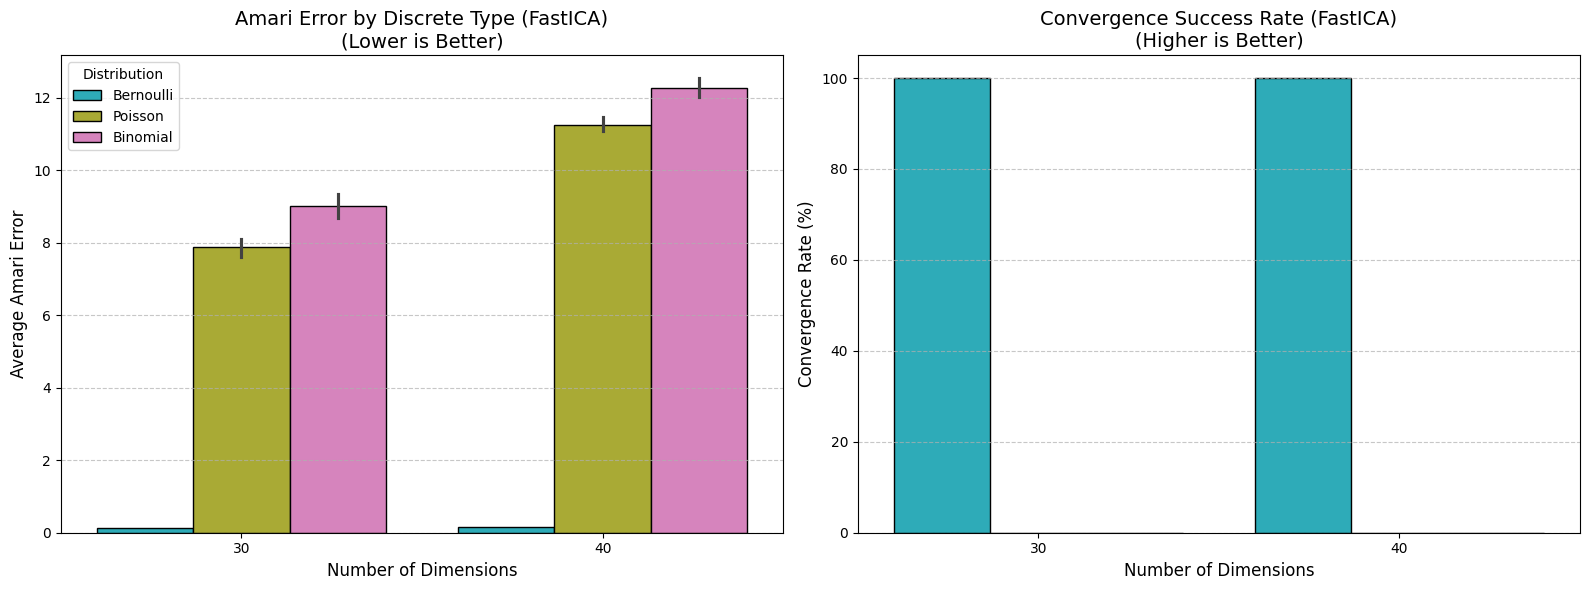

Amari Error  Converged
Dimension Distribution                        
30        Bernoulli          0.1227        1.0
          Binomial           9.0120        0.0
          Poisson            7.8712        0.0
40        Bernoulli          0.1620        1.0
          Binomial          12.2742        0.0
          Poisson           11.2480        0.0

In [19]:
# ==========================================
# 4. Plotting the Results
# ==========================================
df_conv_discrete = df_discrete.groupby(['Dimension', 'Distribution'])['Converged'].mean().reset_index()
df_conv_discrete['Converged'] *= 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

discrete_palette = {
    'Bernoulli': '#17becf', # Cyan
    'Poisson': '#bcbd22',   # Olive
    'Binomial': '#e377c2'   # Pink
}

# Plot 1: Amari Error
sns.barplot(data=df_discrete, x='Dimension', y='Amari Error', hue='Distribution', 
            palette=discrete_palette, edgecolor='black', ax=ax1)
ax1.set_title("Amari Error by Discrete Type (FastICA)\n(Lower is Better)", fontsize=14)
ax1.set_ylabel("Average Amari Error", fontsize=12)
ax1.set_xlabel("Number of Dimensions", fontsize=12)
ax1.grid(True, axis='y', linestyle='--', alpha=0.7)

# Plot 2: Convergence Rate
sns.barplot(data=df_conv_discrete, x='Dimension', y='Converged', hue='Distribution', 
            palette=discrete_palette, edgecolor='black', ax=ax2)
ax2.set_title("Convergence Success Rate (FastICA)\n(Higher is Better)", fontsize=14)
ax2.set_ylabel("Convergence Rate (%)", fontsize=12)
ax2.set_xlabel("Number of Dimensions", fontsize=12)
ax2.set_ylim(0, 105)
ax2.grid(True, axis='y', linestyle='--', alpha=0.7)

ax1.legend(title='Distribution', loc='upper left')
ax2.legend_.remove() 

plt.tight_layout()
plt.show()

display(df_discrete.groupby(['Dimension', 'Distribution'])[['Amari Error', 'Converged']].mean().round(4))

#### Discrete Disribution Seperate test with OT ICA

In [20]:
# ==========================================
# Worker Function for OT-ICA Single Discrete Study
# ==========================================
def run_discrete_ablation_trial_ot(dim, trial, n_samples, dist_type):
    torch.set_num_threads(1) 
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # 1. Generate the isolated discrete pool data
    # (Assuming generate_single_discrete_mixture is still in memory from the FastICA cell)
    X_np, A_true = generate_single_discrete_mixture(n_dim=dim, n_samples=n_samples, dist_type=dist_type, seed=trial)
    X_torch = torch.tensor(X_np, dtype=torch.float32).to(device)
    
    converged = True
    score = np.nan
    
    try:
        # 2. Initialize and whiten
        ica = WassersteinICA(X_torch)
        ica.whiten()
        W_white_np = ica.W_white.cpu().numpy()
        
        extracted_ws = []
        n_restarts = dim * 4 if dim * 4 < 150 else 150
        
        # 3. Deflation Phase (with dithering)
        for _ in range(dim):
            prev = torch.stack(extracted_ws) if extracted_ws else None
            w, _ = ica.optimize_wasserstein2(
                prev_components=prev, 
                max_iter=200, 
                n_restarts=n_restarts, 
                dither_sigma=0.01
            )
            extracted_ws.append(w)
            
        W_deflation_init = torch.stack(extracted_ws)
        
        # 4. Symmetric Stiefel Phase 
        W_stiefel_unmixed = ica.optimize_symmetric(
            n_components=dim, 
            max_iter=400,        
            lr=0.25,             
            init_w=W_deflation_init, 
            optimizer='stiefel',
            use_sinkhorn=False,
            dither_sigma=0.01,   
            batch_size=1024      
        )
        
        # Calculate final error
        W_wass_total = W_stiefel_unmixed.cpu().numpy() @ W_white_np
        score = amari_error(W_wass_total, A_true)
        
    except Exception as e:
        converged = False
        score = np.nan

    return {
        'Dimension': dim, 
        'Distribution': dist_type, 
        'Amari Error': score,
        'Converged': int(converged)
    }

In [21]:
# ==========================================
# Run the OT ICA Discrete Isolation Experiment
# ==========================================
import time

DIMENSIONS = [30, 40]
DIST_TYPES = ['Bernoulli', 'Poisson', 'Binomial']
N_SAMPLES = 10000
N_TRIALS = 5 

print(f"Starting Discrete Isolation Study for OT ICA...")
start_time = time.time()

# Run in parallel
results_discrete_ot = Parallel(n_jobs=-1)(
    delayed(run_discrete_ablation_trial_ot)(dim, trial, N_SAMPLES, dist_type)
    for dim in DIMENSIONS
    for dist_type in DIST_TYPES
    for trial in range(N_TRIALS)
)

print(f"Finished in {(time.time() - start_time)/60:.2f} minutes.")

# Compile results into a DataFrame
df_discrete_ot = pd.DataFrame(results_discrete_ot)

Starting Discrete Isolation Study for OT ICA...
Finished in 5.43 minutes.


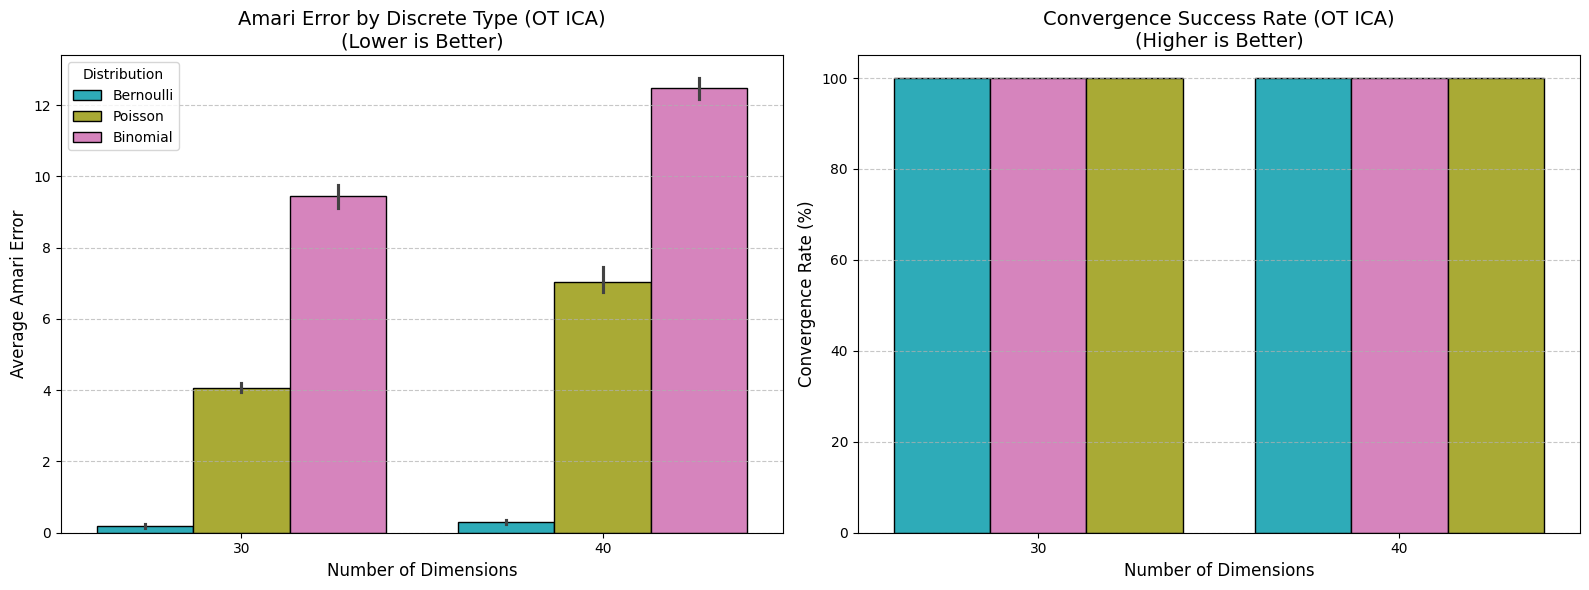

Amari Error  Converged
Dimension Distribution                        
30        Bernoulli          0.1830        1.0
          Binomial           9.4444        1.0
          Poisson            4.0633        1.0
40        Bernoulli          0.3047        1.0
          Binomial          12.4825        1.0
          Poisson            7.0400        1.0

In [22]:
# ==========================================
# Plotting the OT ICA Discrete Results
# ==========================================

# Calculate convergence percentage
df_conv_discrete_ot = df_discrete_ot.groupby(['Dimension', 'Distribution'])['Converged'].mean().reset_index()
df_conv_discrete_ot['Converged'] *= 100

# Set up the matplotlib figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Keep the same color palette as the FastICA discrete test for easy comparison
discrete_palette = {
    'Bernoulli': '#17becf', # Cyan
    'Poisson': '#bcbd22',   # Olive
    'Binomial': '#e377c2'   # Pink
}

# Plot 1: Amari Error Bar Chart
sns.barplot(data=df_discrete_ot, x='Dimension', y='Amari Error', hue='Distribution', 
            palette=discrete_palette, edgecolor='black', ax=ax1)
ax1.set_title("Amari Error by Discrete Type (OT ICA)\n(Lower is Better)", fontsize=14)
ax1.set_ylabel("Average Amari Error", fontsize=12)
ax1.set_xlabel("Number of Dimensions", fontsize=12)
ax1.grid(True, axis='y', linestyle='--', alpha=0.7)

# Plot 2: Convergence Rate Bar Chart
sns.barplot(data=df_conv_discrete_ot, x='Dimension', y='Converged', hue='Distribution', 
            palette=discrete_palette, edgecolor='black', ax=ax2)
ax2.set_title("Convergence Success Rate (OT ICA)\n(Higher is Better)", fontsize=14)
ax2.set_ylabel("Convergence Rate (%)", fontsize=12)
ax2.set_xlabel("Number of Dimensions", fontsize=12)
ax2.set_ylim(0, 105)
ax2.grid(True, axis='y', linestyle='--', alpha=0.7)

# Adjust legends
ax1.legend(title='Distribution', loc='upper left')
ax2.legend_.remove() 

plt.tight_layout()
plt.show()

# Print the final numerical summary
display(df_discrete_ot.groupby(['Dimension', 'Distribution'])[['Amari Error', 'Converged']].mean().round(4))